# Matplotlib Style Recommendations


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import mvdlib.plots

plt.style.use("mvdlib.style.default")
FIGSIZE = mvdlib.plots.FigSize()

## Figure size and axis labels

**Recommendation:** Prefer single column figures. Adhere to journal size recommendations.

**Recommendation:** Use math mode for axes labels.

**Recommendation:** Use division to eliminate units. Use negative exponents to denote units in the denominator.


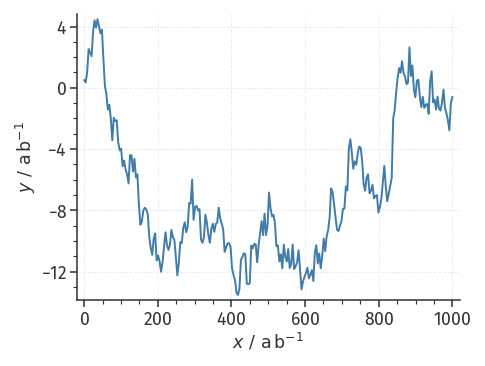

In [2]:
np.random.seed(42)
x = np.linspace(0.0, 1000, 250)
y = np.cumsum(np.random.randn(x.size))

fig, ax = plt.subplots(1, 1, figsize=FIGSIZE())

ax.plot(x, y, color="C1")
ax.set_xlabel(r"$x\ /\ \mathsf{a\,b^{-1}}$")
ax.set_ylabel(r"$y\ /\ \mathsf{a\,b^{-1}}$")
ax.xaxis.set_major_locator(plt.MaxNLocator(6))
ax.yaxis.set_major_locator(plt.MaxNLocator(6))

plt.show()

## Colors

**Recommendation:** Keep colors to a minimum of 3.


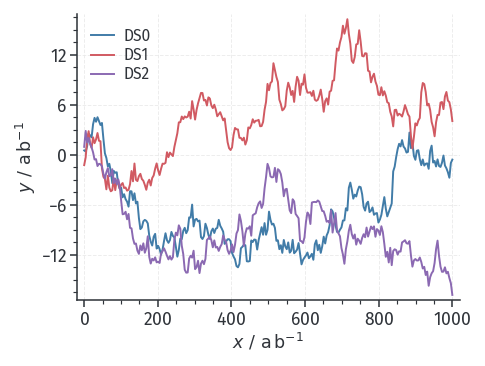

In [3]:
np.random.seed(42)
n = 3
x = np.linspace(0.0, 1000, 250)
y = [np.cumsum(np.random.randn(x.size)) for _ in range(n)]

fig, ax = plt.subplots(1, 1, figsize=FIGSIZE())
for i in range(n):
    ax.plot(x, y[i], color=f"C{i + 1}", label=f"DS{i}")

ax.legend()
ax.set_xlabel(r"$x\ /\ \mathsf{a\,b^{-1}}$")
ax.set_ylabel(r"$y\ /\ \mathsf{a\,b^{-1}}$")
ax.xaxis.set_major_locator(plt.MaxNLocator(6))
ax.yaxis.set_major_locator(plt.MaxNLocator(6))

plt.show()

## Highlights and Transparency

**Recommendation:** Try to use highlight colors and/or transparency when plotting many lines.


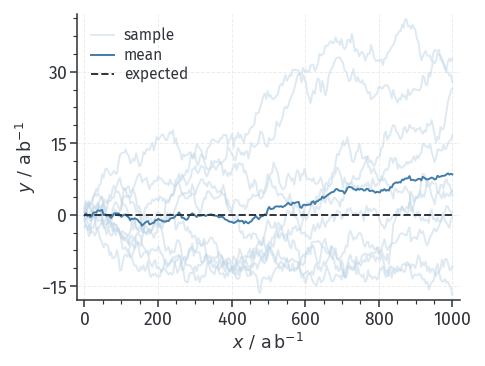

In [4]:
np.random.seed(42)
n = 10
x = np.linspace(0.0, 1000, 250)
y = [np.cumsum(np.random.randn(x.size)) for _ in range(n)]

fig, ax = plt.subplots(1, 1, figsize=FIGSIZE())
for i in range(n):
    ax.plot(x, y[i], color="C4", alpha=0.5)
ax.plot([], [], color="C4", alpha=0.5, label="sample")
ax.plot(x, np.mean(y, axis=0), color="C1", label="mean")
ax.plot(x, np.zeros_like(x), color="C0", label="expected", ls="--")

ax.legend()
ax.set_xlabel(r"$x\ /\ \mathsf{a\,b^{-1}}$")
ax.set_ylabel(r"$y\ /\ \mathsf{a\,b^{-1}}$")
ax.xaxis.set_major_locator(plt.MaxNLocator(6))
ax.yaxis.set_major_locator(plt.MaxNLocator(6))

plt.show()

## Sequential color maps

**Recommendation:** Use sequential colormaps to discriminate data that is connected by some hidden variable, like time.


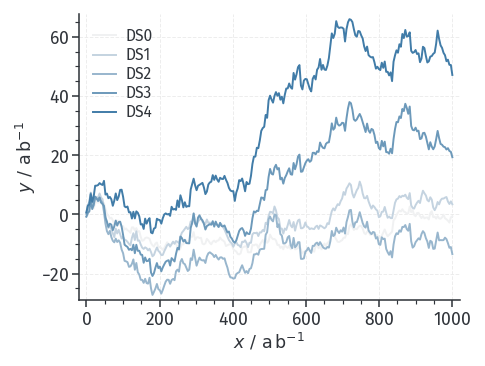

In [5]:
np.random.seed(42)

n = 5
x = np.linspace(0.0, 1000, 250)
ys = [np.cumsum(np.random.randn(x.size)) for _ in range(n)]
ys = np.cumsum(ys, axis=0)

fig, ax = plt.subplots(1, 1, figsize=FIGSIZE())
colors = sns.color_palette("light:C1", n)
for i in range(n):
    ax.plot(x, ys[i], color=colors[i], label=f"DS{i}")

ax.legend(ncol=1)
ax.set_xlabel(r"$x\ /\ \mathsf{a\,b^{-1}}$")
ax.set_ylabel(r"$y\ /\ \mathsf{a\,b^{-1}}$")
ax.xaxis.set_major_locator(plt.MaxNLocator(6))
ax.yaxis.set_major_locator(plt.MaxNLocator(6))

plt.show()

## Column layouts

**Recommendation:** Use columns for shared y-axes. Use axes titles for designating panels. Adhere to journal size recommendations.


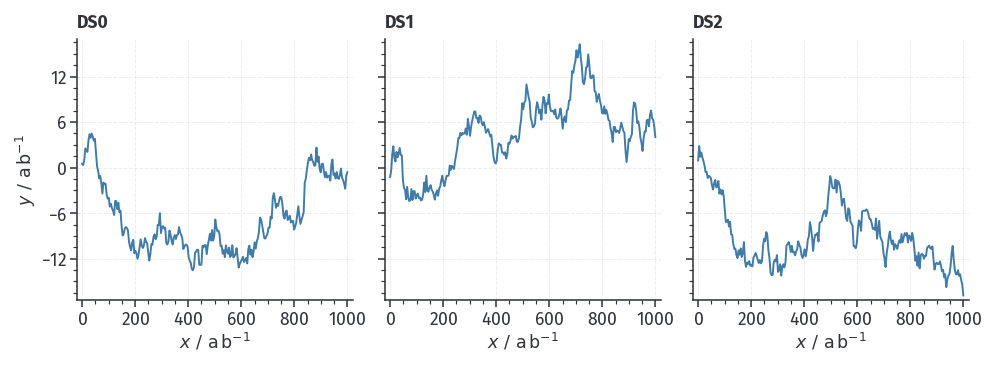

In [6]:
np.random.seed(42)

ncols = 3
x = np.linspace(0.0, 1000, 250)
y = [np.cumsum(np.random.randn(x.size)) for _ in range(ncols)]

fig, axes = plt.subplots(
    1, ncols, figsize=FIGSIZE(2), sharex=True, sharey=True
)
for i in range(ncols):
    axes[i].plot(x, y[i], color="C1")
    axes[i].set_title(f"DS{i}")
    axes[i].set_xlabel(r"$x\ /\ \mathsf{a\,b^{-1}}$")

axes[0].set_ylabel(r"$y\ /\ \mathsf{a\,b^{-1}}$")
axes[0].xaxis.set_major_locator(plt.MaxNLocator(6))
axes[0].yaxis.set_major_locator(plt.MaxNLocator(6))

plt.show()

## Row layouts

**Recommendation:** Use rows for shared x-axes.


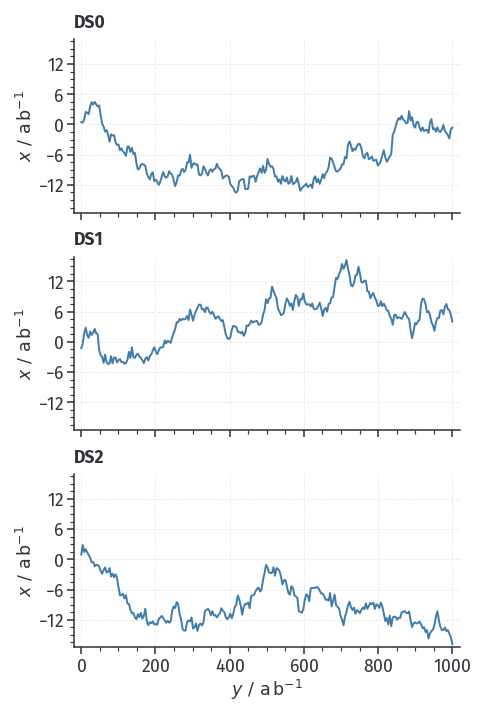

In [7]:
np.random.seed(42)

nrows = 3
x = np.linspace(0.0, 1000, 250)
y = [np.cumsum(np.random.randn(x.size)) for _ in range(nrows)]

fig, axes = plt.subplots(
    nrows, 1, figsize=FIGSIZE(1, 5.0), sharex=True, sharey=True
)
for i in range(nrows):
    axes[i].plot(x, y[i], color="C1")
    axes[i].set_title(f"DS{i}")
    axes[i].set_ylabel(r"$x\ /\ \mathsf{a\,b^{-1}}$")

axes[-1].set_xlabel(r"$y\ /\ \mathsf{a\,b^{-1}}$")
axes[-1].xaxis.set_major_locator(plt.MaxNLocator(6))
axes[-1].yaxis.set_major_locator(plt.MaxNLocator(6))

plt.show()

## Meshes and contours

**Recommendation:** Use color meshes and contours to represent a third dimension.

**Recommendation:** Set equal aspect ratios for x- and y-axes with the same magnitude.


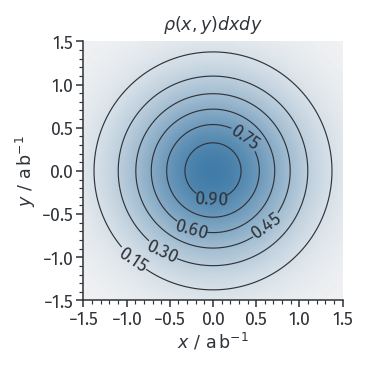

In [8]:
x = np.linspace(-1.5, 1.5, 250)
y = np.linspace(-1.5, 1.5, 250)
x, y = np.meshgrid(x, y)
z = np.exp(-(x ** 2) - y ** 2)

fig, ax = plt.subplots(1, 1, figsize=FIGSIZE())
mesh, contourset = mvdlib.plots.contourplot(ax, x, y, z, cmap=sns.color_palette("light:C1", 256, as_cmap=True))

ax.set_aspect("equal")
ax.set_xlabel(r"$x\ /\ \mathsf{a\,b^{-1}}$")
ax.set_ylabel(r"$y\ /\ \mathsf{a\,b^{-1}}$")
ax.set_title(r"$\rho(x, y)dxdy$", loc="center")
ax.xaxis.set_major_locator(plt.MaxNLocator(6))
ax.yaxis.set_major_locator(plt.MaxNLocator(6))

plt.show()

## Diverging color maps

**Recommendation:** Use diverging color maps when displaying diverging data.


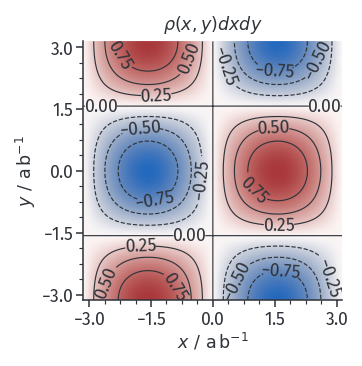

In [9]:
x = np.linspace(-np.pi, np.pi, 250)
y = x
x, y = np.meshgrid(x, y)
z = np.sin(x) * np.cos(y)

fig, ax = plt.subplots(1, 1, figsize=FIGSIZE())
mvdlib.plots.contourplot(ax, x, y, z, cmap="vlag")

ax.set_aspect("equal")
ax.set_xlabel(r"$x\ /\ \mathsf{a\,b^{-1}}$")
ax.set_ylabel(r"$y\ /\ \mathsf{a\,b^{-1}}$")
ax.set_title(r"$\rho(x, y)dxdy$", loc="center")
ax.xaxis.set_major_locator(plt.MaxNLocator(6))
ax.yaxis.set_major_locator(plt.MaxNLocator(6))

plt.show()

## Bar plots

**Recommendation:** Add values when showing bar plots.


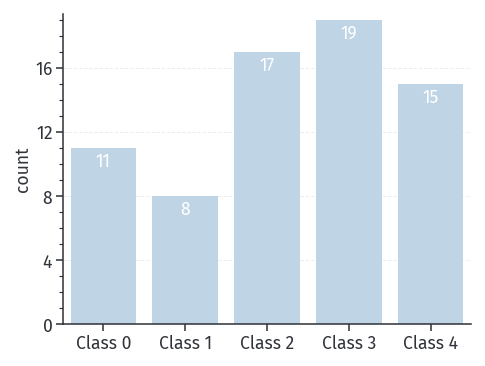

In [10]:
np.random.seed(42)
n = 5
classes = [f"Class {i}" for i in range(n)]
values = np.random.randint(5, 20, n)

fig, ax = plt.subplots(1, 1, figsize=FIGSIZE())
ax.bar(classes, values, color="C4")
ax.xaxis.set_minor_locator(plt.NullLocator())
ax.yaxis.set_major_locator(plt.MaxNLocator(6))
ax.grid(axis="x")
ax.set_ylabel("count")

for i in range(n):
    ax.text(
        i,
        values[i] - 0.3,
        f"{values[i]}",
        ha="center",
        va="top",
        color="white",
    )

plt.show()

## Kernel density estimation

**Recommendation:** Use kernel density estimation to show the distribution of data.


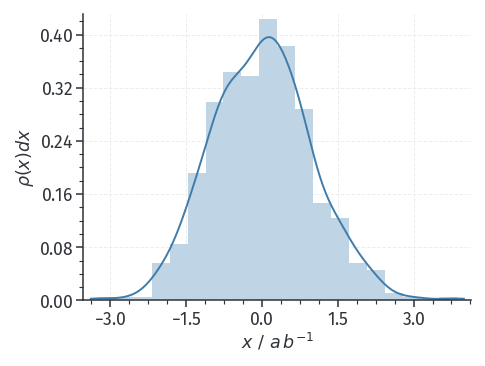

In [11]:
np.random.seed(42)
n = 500
x = np.random.randn(n)

fig, ax = plt.subplots(1, 1, figsize=FIGSIZE())
ax.hist(x, density=True, color="C4")
mvdlib.plots.kdeplot(ax, x, color="C1")

ax.xaxis.set_major_locator(plt.MaxNLocator(6))
ax.yaxis.set_major_locator(plt.MaxNLocator(6))
ax.set_xlabel(r"$x\ /\ a\,b^{-1}$")
ax.set_ylabel(r"$\rho(x)dx$")

plt.show()